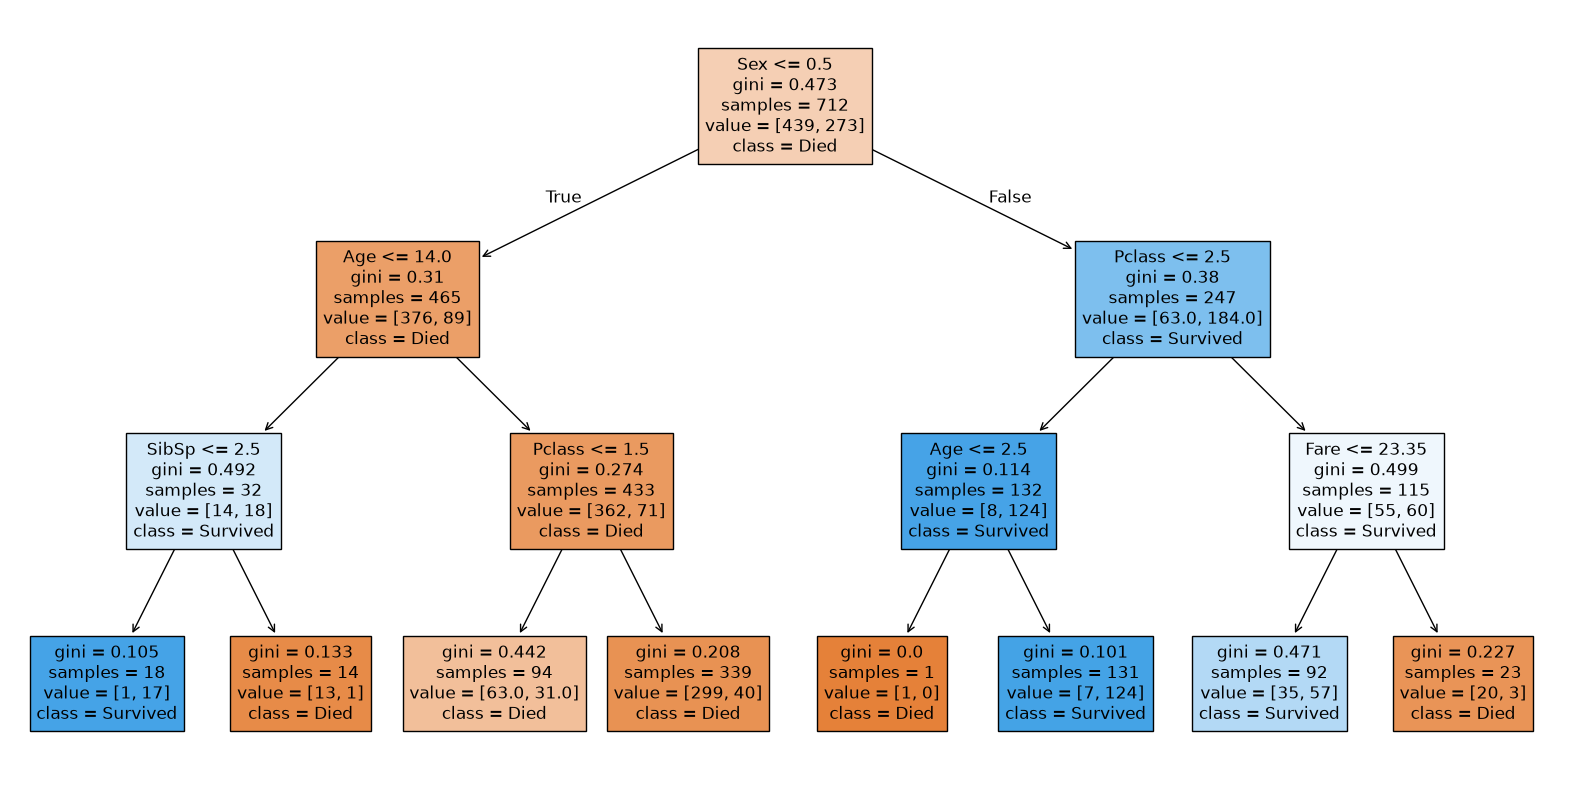

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(display='text')

df=pd.read_csv('../data/titanic/train.csv', encoding='utf-8')

X=df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y=df['Survived']

X['Sex']=X['Sex'].map({'male':0,'female':1})
X['Embarked'] = X['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X_train,X_valid,y_train,y_valid = train_test_split(X,y,test_size=0.2,random_state=0)

model = DecisionTreeClassifier(max_depth=3,random_state=0)
model.fit(X_train,y_train)

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True)
plt.show()



## 決定木(Decision Tree)の学習メモ

### 木の読み方
- 各ノードの1行目 = 分岐条件（例: `Age <= 14.0`）
- 2行目以降 = `gini`(不純度), `samples`(データ数), `value`(クラス内訳), `class`(多数派予測)
- 色の濃さ = `value`の偏り具合をそのまま可視化したもの（濃い=ほぼ確定、薄い=五分五分）
- モデルの最終予測は必ず**葉(leaf)**まで辿り着いて決まる。途中のノードの色は参考情報でしかない

### random_stateの違い
- `train_test_split`の`random_state` → **どのデータを**train/testに振り分けるかのシード
- `DecisionTreeClassifier`の`random_state` → 木を**育てる過程**で、同点(タイ)の分岐候補があった時にどちらを採用するかのシード
- 対象のレイヤーが違うだけで、どちらも「乱数を固定して再現性を持たせる」という目的は同じ

In [2]:
y_pred= model.predict(X_valid)

from sklearn.metrics import accuracy_score
accuracy_score(y_valid,y_pred)


0.8212290502793296

### 評価指標

**Confusion Matrix（混同行列）**: True(実際)×Predicted(予測)の4マスで、予測がどう当たった/外れたかを個票ベースで集計したもの。対角線=正解、対角線の外=誤り。

**Precision（適合率）** = 列方向の割合。予測で「そのクラス」とした人のうち、実際に合っていた割合。**モデル自身の発言の信頼度**。
**Recall（再現率）** = 行方向の割合。実際に「そのクラス」だった人のうち、正しく拾えた割合。**現実をどれだけ取りこぼさず反映できているか**。
→ 見逃しが致命的な場面はRecall重視、誤報のコストが高い場面はPrecision重視。

**accuracy**: 全体の正解率。
**macro avg**: クラスごとの指標を人数を無視して単純平均。少数派クラスの弱点を隠さず暴く。
**weighted avg**: クラスごとの指標を人数で重み付けして平均。ほぼaccuracyと同じ意味になりがちで、実務での優先度は低め。

→ 実務の優先順位: ①accuracyで全体像 → ②各クラスのprecision/recall(またはmacro avg)で隠れた弱点をチェック → ③weighted avgはおまけ程度。

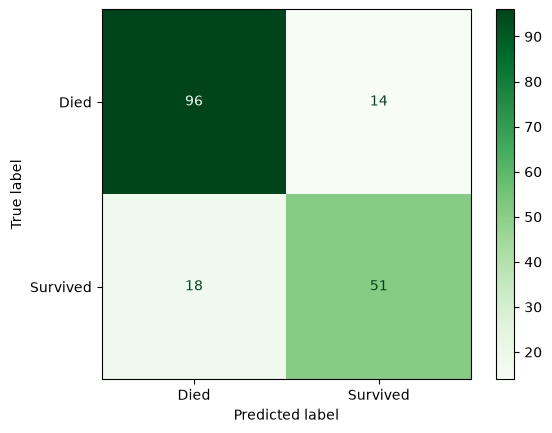

[[96 14]
 [18 51]]


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_valid)

cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died',
 'Survived'])
disp.plot(cmap='Greens')
plt.show()

print(cm)

In [5]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_valid)
print(classification_report(y_valid, y_pred, target_names=['Died', 'Survived']))

              precision    recall  f1-score   support

        Died       0.84      0.87      0.86       110
    Survived       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Sex         0.621926
Pclass      0.176426
SibSp       0.075520
Age         0.070737
Fare        0.055391
Parch       0.000000
Embarked    0.000000
dtype: float64


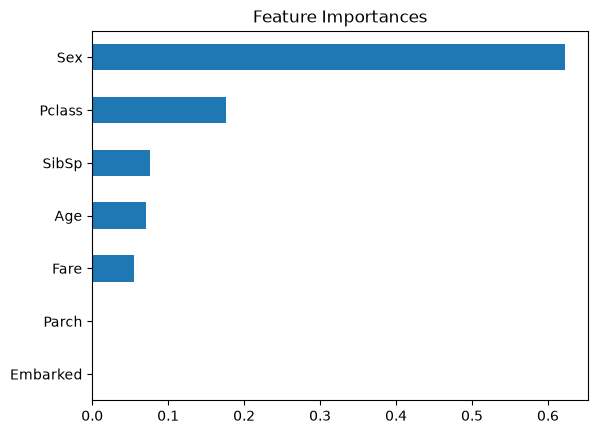

In [7]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importances')
plt.show()

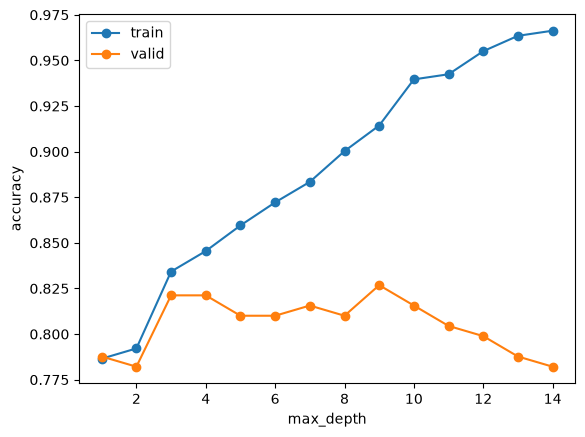

In [8]:
train_scores = []
valid_scores = []
depths = range(1, 15)

for depth in depths:
    m = DecisionTreeClassifier(max_depth=depth, random_state=0)
    m.fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    valid_scores.append(m.score(X_valid, y_valid))

plt.plot(depths, train_scores, marker='o', label='train')
plt.plot(depths, valid_scores, marker='o', label='valid')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': range(1, 15)}

grid = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5)
grid.fit(X_train, y_train)

print('best max_depth:', grid.best_params_)
print('best cv score:', grid.best_score_)
print('valid score with best model:', grid.best_estimator_.score(X_valid, y_valid))

best max_depth: {'max_depth': 4}
best cv score: 0.8159755737220526
valid score with best model: 0.8212290502793296


In [12]:
# 同じデータ・同じmax_depthでも、木を作るときのrandom_stateだけ変えるとどうなるか
for rs in range(5):
    m = DecisionTreeClassifier(max_depth=4, random_state=rs)
    m.fit(X_train, y_train)
    top_feature = X.columns[m.feature_importances_.argmax()]
    print(f'random_state={rs}: top feature={top_feature}, valid score={m.score(X_valid, y_valid):.3f}')

random_state=0: top feature=Sex, valid score=0.821
random_state=1: top feature=Sex, valid score=0.821
random_state=2: top feature=Sex, valid score=0.821
random_state=3: top feature=Sex, valid score=0.821
random_state=4: top feature=Sex, valid score=0.821


### 過学習とmax_depth
- depthを深くするほどtrain accuracyは上がり続けるが、validはどこかで頭打ち→下降する（過学習）
- 手動グラフ・GridSearchCV(cv=5)どちらでも今回のデータでは `max_depth=3〜4` あたりが妥当という結論で一致した

### 決定木単体の弱点と、ランダムフォレスト/GBMへの繋がり
- 決定木は「if-elseの分岐」でできているため、データがわずかに変わるだけで根っこの分岐条件が僅差で逆転し、木全体の構造がガラッと変わりやすい（不安定）
- 対策: 条件を少しずつ変えた木をたくさん作って多数決を取る → **ランダムフォレスト**（バギング）
- 別解: 1本の木の間違いを次の木が補正していく → **GBM/XGBoost/LightGBM**（ブースティング）
- 決定木単体は実務の主力にはなりにくいが、これらアンサンブル手法の部品として理解必須。かつ解釈性が高く説明用途にも使われる。